In [12]:
import spatialdata as sd
import scanpy as sc
import squidpy as sq
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import decoupler
import seaborn.objects as so

In [24]:
sdata = sd.read_zarr("Version 2 Baysor Zarr//Sample_3H_annotated.zarr")

In [25]:
sdata.tables["Baysor"].obs["donor"] = "3"
sdata.tables["Baysor"].obs["condition"] = "diseased"
sdata.tables["Baysor"].obs["sample"] = "3H"

In [26]:
adata = sdata.tables["Baysor"]
adata.write_h5ad("Version 2 Baysor Zarr//adata_3H_baysor.h5ad")

In [10]:
adata_1H = sc.read_h5ad("Version 2 Baysor Zarr//adata_1H_baysor.h5ad")
adata_1D = sc.read_h5ad("Version 2 Baysor Zarr//adata_1D_baysor.h5ad")
adata_2D = sc.read_h5ad("Version 2 Baysor Zarr//adata_2D_baysor.h5ad")
adata_2H = sc.read_h5ad("Version 2 Baysor Zarr//adata_2H_baysor.h5ad")
adata_3D = sc.read_h5ad("Version 2 Baysor Zarr//adata_3D_baysor.h5ad")
adata_3H = sc.read_h5ad("Version 2 Baysor Zarr//adata_3H_baysor.h5ad")
adata_4D = sc.read_h5ad("Version 2 Baysor Zarr//adata_4D_baysor.h5ad")
adata_4H = sc.read_h5ad("Version 2 Baysor Zarr//adata_4H_baysor.h5ad")
adata_merged = adata_1H.concatenate(adata_1D, adata_2D, adata_2H, adata_3D, adata_3H, adata_4D, adata_4H)

C:\Users\laure\AppData\Local\Temp\ipykernel_5720\3849901065.py:9: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = adata_1H.concatenate(adata_1D, adata_2D, adata_2H, adata_3D, adata_3H, adata_4D, adata_4H)


In [15]:
adata.var

,gene_ids,feature_types
AAK1,AAK1,Gene Expression
ABCA1,ABCA1,Gene Expression
ABCC9,ABCC9,Gene Expression
ABCG1,ABCG1,Gene Expression
ACOT11,ACOT11,Gene Expression
...,...,...
XRCC1,XRCC1,Gene Expression
YAP1,YAP1,Gene Expression
ZEB2,ZEB2,Gene Expression
ZNF683,ZNF683,Gene Expression


In [14]:
adata_merged.write_h5ad("Version 2 Baysor Zarr//adata_merged_baysor.h5ad")

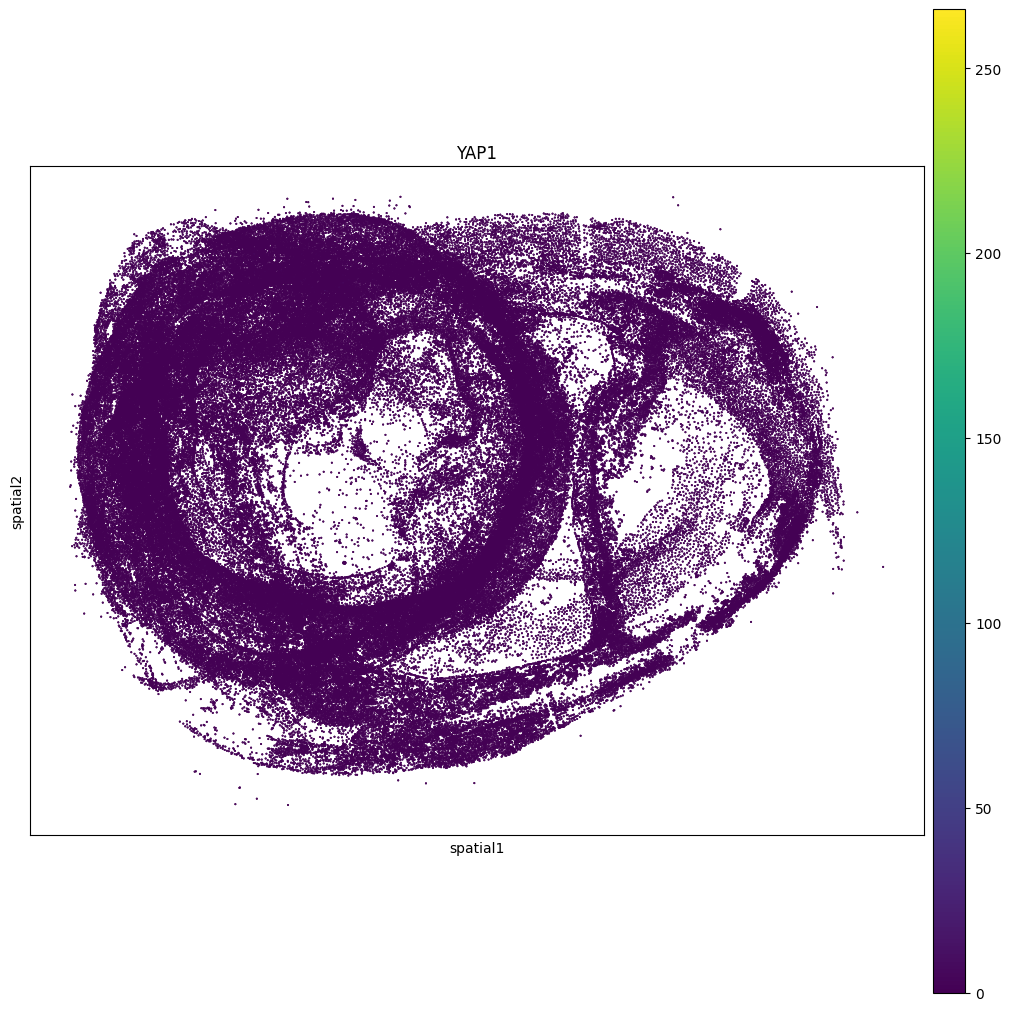

In [17]:
sq.pl.spatial_scatter(
    adata_merged, color=["YAP1"], shape=None, figsize=(10, 10)
)

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


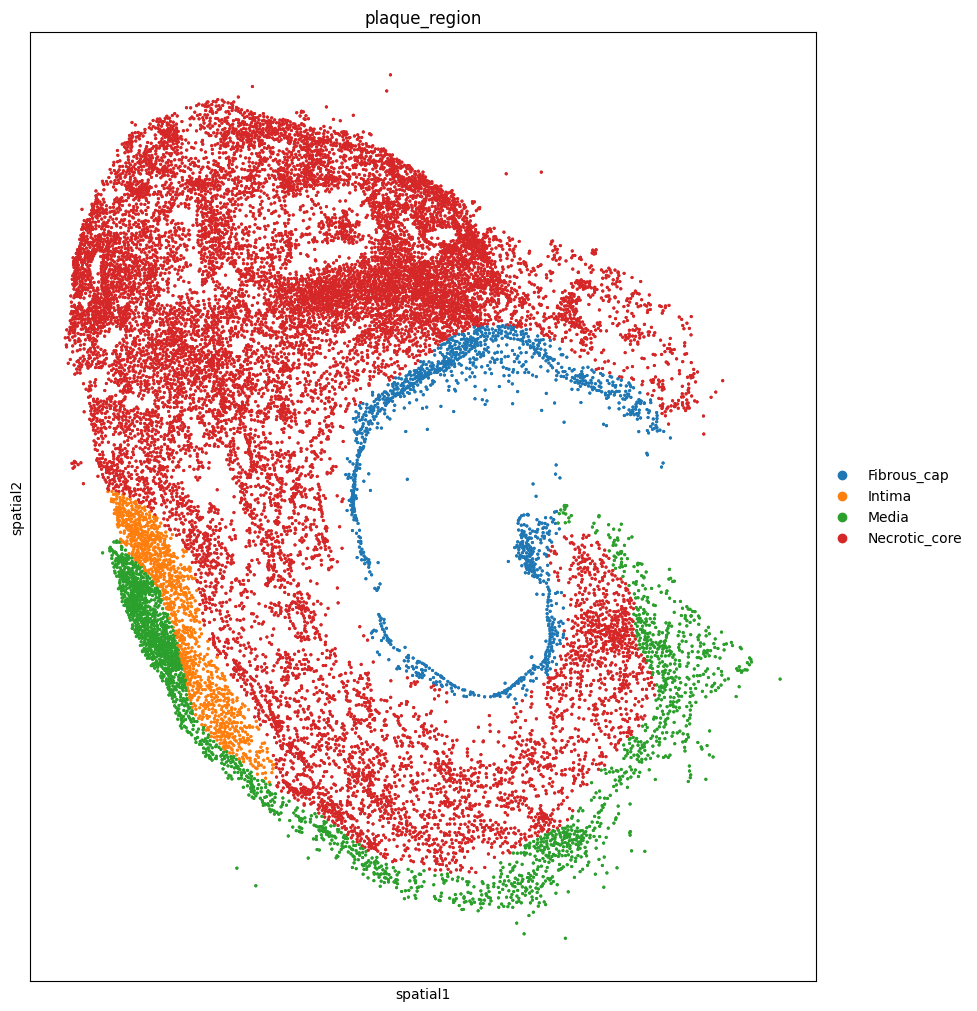

In [25]:
sq.pl.spatial_scatter(
    sdata.tables["Baysor"], color=["plaque_region"], shape=None, figsize=(10, 10)
)

In [26]:
n_obs_change = {"1D": [9829,15967],"1H":[6342,9108], "2H": [6776,14193],"2D": [21723,9563] ,"3D": [11521,19310],"3H": [9878,15012], "4D": [25207,34747], "4H": [18784,25514]}

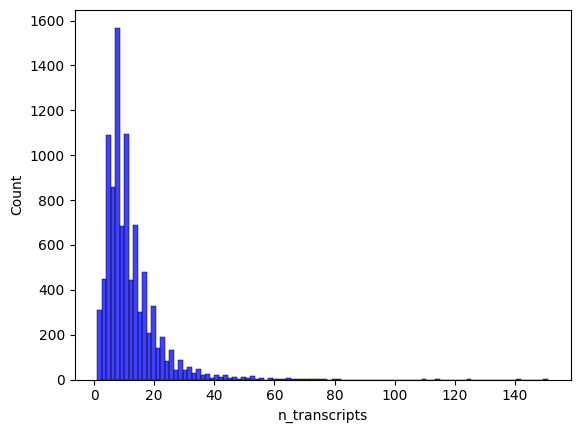

In [14]:
histplot = sns.histplot(sdata.tables["Baysor"].obs["n_transcripts"], color="blue", bins=100)
fig = histplot.get_figure()
fig.savefig("plots//n_transcripts_by_cell_2D_Baysor.png", dpi=300)

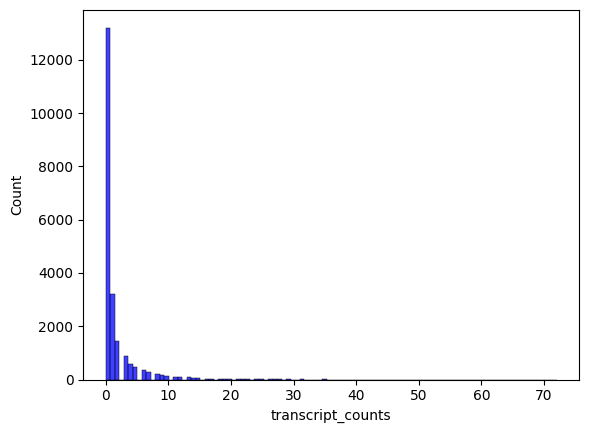

In [15]:
histplot = sns.histplot(sdata.tables["table"].obs["transcript_counts"], color="blue", bins=100)
fig = histplot.get_figure()
fig.savefig("plots//n_transcript_cell_2D_Xenium.png", dpi=300)

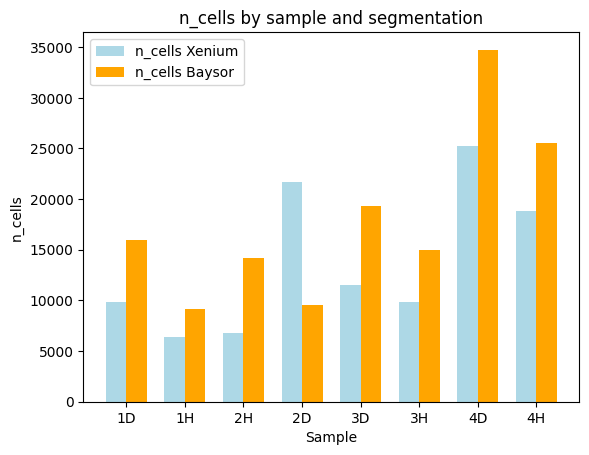

In [28]:
labels = list(n_obs_change.keys())
values = list(n_obs_change.values())

# Separate the first and second values
values1 = [v[0] for v in values]
values2 = [v[1] for v in values]

# Define the x positions
x = np.arange(len(labels))

# Define the width of the bars
width = 0.35

# Plot the bars
fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, values1, width, label='n_cells Xenium', color='lightblue')
bar2 = ax.bar(x + width/2, values2, width, label='n_cells Baysor', color='orange')

# Add labels, title, and legend
ax.set_xlabel('Sample')
ax.set_ylabel('n_cells')
ax.set_title('n_cells by sample and segmentation')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Show the plot
plt.savefig('plots//n_cells_by_sample_by_segmentation.png', format='png', dpi=300)


In [2]:
adata = sc.read_h5ad("Version 2 Baysor cell type Zarr//All_samples_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 124799 × 344
    obs: 'cell', 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'plaque_region', 'sample', 'donor', 'condition', 'n_counts', 'leiden', 'cell_type', 'batch'
    var: 'gene_ids', 'feature_types'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [4]:
unknown = adata[adata.obs["cell_type"] == "unknown"]
unknown

View of AnnData object with n_obs × n_vars = 31772 × 344
    obs: 'cell', 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'plaque_region', 'sample', 'donor', 'condition', 'n_counts', 'leiden', 'cell_type', 'batch'
    var: 'gene_ids', 'feature_types'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [8]:
sc.tl.rank_genes_groups(adata, 'cell_type', method='wilcoxon', key_added = "wilcoxon", corr_method='bonferroni')

In [9]:
names = adata.uns["wilcoxon"]["names"]
pvals = adata.uns["wilcoxon"]["pvals"]
pvals_adj = adata.uns["wilcoxon"]["pvals_adj"]
logFC = adata.uns["wilcoxon"]["logfoldchanges"]

In [10]:
for cell_type in ["unknown"]:
    data = []
    if cell_type in names.dtype.names:
        for i in range(len(names)):
            data.append((names[i][cell_type], pvals[i][cell_type], pvals_adj[i][cell_type], logFC[i][cell_type]))
        df = pd.DataFrame(data, columns=['gene', 'pvals', 'pvals_adj', 'logfc'])
        df.to_csv(f"DEGs//unknown_vs_rest_DEGs.csv", index=False)

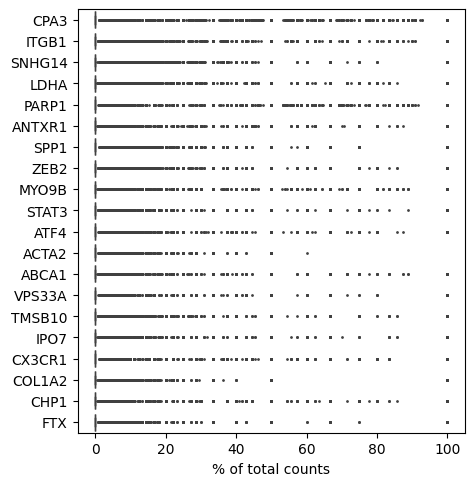

In [12]:
sc.pl.highest_expr_genes(unknown, n_top=20)

In [13]:
cell_counts = np.array(adata.X.sum(axis=1)).flatten()

# Count cells with zero total counts
zero_count_cells = np.sum(cell_counts == 0)

print(f"Number of cells with zero counts: {zero_count_cells}")

Number of cells with zero counts: 0


In [2]:
# Retrieving via python
msigdb = decoupler.get_resource("MSigDB")

# Get reactome pathways
reactome = msigdb.query("collection == 'reactome_pathways'")
# Filter duplicates
reactome = reactome[~reactome.duplicated(("geneset", "genesymbol"))]

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: omnipath is not installed. Please install it by: `pip install omnipath`.

In [3]:
df = pd.read_csv('GSEA//Prepared_Pathway_Data.csv', usecols=[0, 2, 3], index_col=0)
df = df.rename(columns={'pathway_name': 'geneset', 'gene': 'genesymbol'})
df = df[[df.columns[1], df.columns[0]]]
df['geneset'] = df['geneset'].str.replace(' ', '_')

,geneset,genesymbol
1,Interleukin-6_signaling,JAK1
2,Interleukin-6_signaling,STAT1
3,Interleukin-6_signaling,PTPN11
4,Interleukin-6_signaling,CBL
5,Interleukin-6_signaling,JAK1
...,...,...
132779,Signaling_by_the_B_Cell_Receptor_(BCR),CD79A
132780,Signaling_by_the_B_Cell_Receptor_(BCR),ITPR1
132781,Signaling_by_the_B_Cell_Receptor_(BCR),STIM1
132782,Signaling_by_the_B_Cell_Receptor_(BCR),UBB


In [8]:
df_unique = df.drop_duplicates(subset=['geneset', 'genesymbol'])

In [4]:
# Filtering genesets to match behaviour of fgsea
geneset_size = df.groupby("geneset").size()
gsea_genesets = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)]

In [28]:
t_stats_up = pd.read_csv('DEGs//unknown_Media_pb_DEGs.csv', index_col=0)
t_stats_up = t_stats_up.sort_values("log2FoldChange", key=np.abs, ascending=False)
t_stats_up = t_stats_up[["log2FoldChange"]]
t_stats_up = t_stats_up[t_stats_up["log2FoldChange"] > 0]
t_stats_up

,log2FoldChange
SPP1,4.071013
RAMP3,3.013619
CPA3,2.815272
IFI30,2.804419
TEAD3,2.395123
...,...
SIRT1,0.036347
OAS1,0.027204
UMPS,0.027018
LINGO1,0.025180


In [27]:
t_stats_down = pd.read_csv('DEGs//unknown_Media_pb_DEGs.csv', index_col=0)
t_stats_down = t_stats_down.sort_values("log2FoldChange", key=np.abs, ascending=False)
t_stats_down = t_stats_down[["log2FoldChange"]]
t_stats_down = -t_stats_down[t_stats_down["log2FoldChange"] > 0]
t_stats_down

,log2FoldChange
SPP1,-4.071013
RAMP3,-3.013619
CPA3,-2.815272
IFI30,-2.804419
TEAD3,-2.395123
...,...
SIRT1,-0.036347
OAS1,-0.027204
UMPS,-0.027018
LINGO1,-0.025180


In [29]:
scores, norm, pvals = decoupler.run_gsea(
    t_stats_up.T,
    df_unique[df_unique["geneset"].isin(gsea_genesets)],
    source="geneset",
    target="genesymbol",
)

gsea_results = (
    pd.concat({"score": scores.T, "norm": norm.T, "pval": pvals.T}, axis=1)
    .droplevel(level=1, axis=1)
    .sort_values("pval")
)

In [30]:
gsea_results

,score,norm,pval
source,,,
ER-Phagosome_pathway,0.734671,1.411024,0.047938
Toll-like_Receptor_Cascades,0.710261,1.411730,0.053493
Toll_Like_Receptor_4_(TLR4)_Cascade,0.732847,1.419873,0.056180
Antigen_processing-Cross_presentation,0.659501,1.326203,0.092357
Class_I_MHC_mediated_antigen_processing_&_presentation,0.645241,1.318956,0.099682
Regulation_of_TLR_by_endogenous_ligand,0.706859,1.318612,0.107675
Neutrophil_degranulation,0.546081,1.228423,0.137412
Toll_Like_Receptor_2_(TLR2)_Cascade,0.686767,1.285414,0.141379
MyD88:MAL(TIRAP)_cascade_initiated_on_plasma_membrane,0.686767,1.285414,0.141379


In [31]:
gsea_results['log_pval'] = -np.log10(gsea_results['pval'])
gsea_results["source"] = gsea_results.index 
gsea_results = gsea_results.sort_values(by="log_pval", ascending=True)

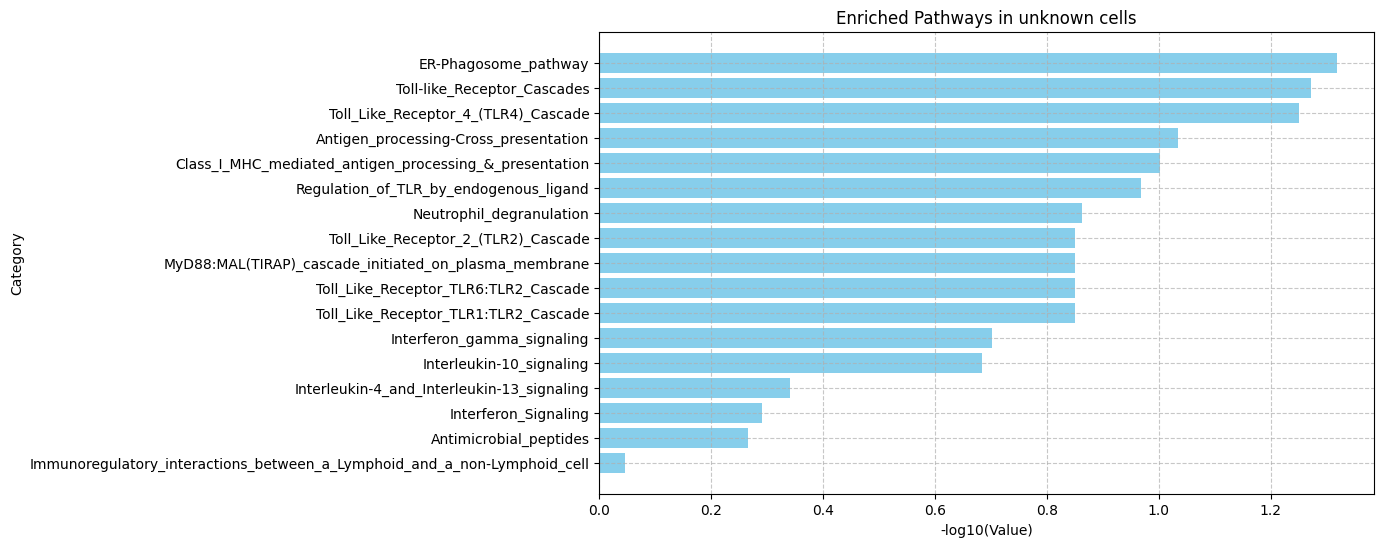

In [33]:
# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(gsea_results.index, gsea_results['log_pval'], color='skyblue')

# Add labels
plt.xlabel('-log10(Value)')
plt.ylabel('Category')
plt.title('Enriched Pathways in unknown cells')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [46]:
sdata = sd.read_zarr("Version 2 Baysor cell type Zarr//Sample_2H_annotated.zarr")

In [47]:
sdata

SpatialData object, with associated Zarr store: C:\Users\laure\Desktop\github\Masterpraktikum\main_task\Version 2 Baysor cell type Zarr\Sample_2H_annotated.zarr
├── Images
│     ├── '1_2H_tiff': DataTree[cyx] (4, 883, 508), (4, 441, 254), (4, 220, 127), (4, 110, 63)
│     └── 'morphology_focus': DataTree[cyx] (1, 23945, 45415), (1, 11972, 22707), (1, 5986, 11353), (1, 2993, 5676), (1, 1496, 2838)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (23945, 45415), (11972, 22707), (5986, 11353), (2993, 5676), (1496, 2838)
│     └── 'nucleus_labels': DataTree[yx] (23945, 45415), (11972, 22707), (5986, 11353), (2993, 5676), (1496, 2838)
├── Points
│     ├── 'HE_landmarks': DataFrame with shape: (<Delayed>, 2) (2D points)
│     ├── 'Xenium_landmarks': DataFrame with shape: (<Delayed>, 2) (2D points)
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'Intima': GeoDataFrame shape: (1, 1) (2D shapes)
│     ├── 'Media': GeoDataFrame shape: (1, 1) (2D sh

In [39]:
adata = sc.read_h5ad("Version 2 Baysor cell type Zarr//All_samples_annotated.h5ad")

In [43]:
sc.pp.filter_cells(adata, min_genes=3)
sc.pp.filter_genes(adata, min_counts=3)
adata

AnnData object with n_obs × n_vars = 109071 × 344
    obs: 'cell', 'x', 'y', 'z', 'cluster', 'n_transcripts', 'density', 'elongation', 'area', 'avg_confidence', 'avg_assignment_confidence', 'max_cluster_frac', 'lifespan', 'plaque_region', 'sample', 'donor', 'condition', 'n_counts', 'leiden', 'cell_type', 'batch', 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_counts'
    obsm: 'X_pca', 'X_umap', 'spatial'

In [44]:
adata.write_h5ad("Version 2 Baysor cell type Zarr//All_samples_annotated_min_3_counts_and_genes.h5ad")